In [1]:
import pandas as pd
import numpy as np
from warnings import filterwarnings
filterwarnings("ignore")
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../artifacts/datasets/EasyVisa.csv")

In [3]:
df.shape

(25480, 12)

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
df.isnull().sum()>0

case_id                  False
continent                False
education_of_employee    False
has_job_experience       False
requires_job_training    False
no_of_employees          False
yr_of_estab              False
region_of_employment     False
prevailing_wage          False
unit_of_wage             False
full_time_position       False
case_status              False
dtype: bool

In [6]:
df.duplicated().sum()>0

np.False_

In [7]:
from datetime import date

In [8]:
current_year = date.today().year
df['company_age'] = current_year - df['yr_of_estab']

In [9]:
df = df.drop(columns=['yr_of_estab', 'case_id'])
# df = df.drop(columns=['case_id'])

In [10]:
df.dtypes

continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
case_status                  str
company_age                int64
dtype: object

In [11]:
cat_features = [x for x in df.columns if df[x].dtype == 'str']

num_features = [x for x in df.columns if df[x].dtype != 'str']

In [12]:
X = df.drop(columns=['case_status'])
y_cat = df['case_status']

In [13]:
y = np.where(y_cat == 'Denied', 0, 1)

In [14]:
cat_features.remove('case_status')

In [15]:
cat_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position']

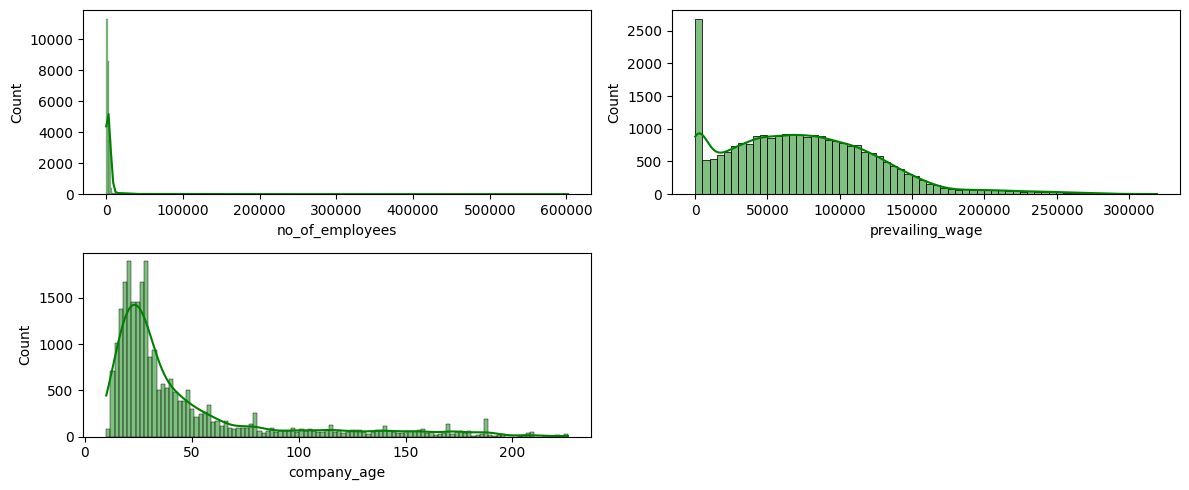

In [16]:
plt.figure(figsize=(12,5))

for i, j in enumerate(num_features):
    plt.subplot(2,2, i+1)
    sns.histplot(df[j], kde=True, color='green')
    plt.tight_layout()

In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [19]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()
pt = PowerTransformer(method='yeo-johnson')

In [20]:
transformer = Pipeline(
    steps=[
        ('transformer', pt)
    ]
)

preprocessor = ColumnTransformer(
    [
        ('ohe', ohe, cat_features),
        ('transformer', transformer, num_features),
        ('scaler', scaler, num_features)
    ]
)

In [21]:
X = preprocessor.fit_transform(X)

In [22]:
from imblearn.combine import SMOTEENN, SMOTETomek

In [23]:
smt = SMOTEENN(random_state=20, n_jobs=-1, sampling_strategy='auto')
X_res, y_res = smt.fit_resample(X, y)

In [24]:
print(X.shape, X_res.shape, y.shape, y_res.shape)

(25480, 31) (17473, 31) (25480,) (17473,)


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.33, random_state=42)
print(X_train.shape, X_test.shape)

(11706, 31) (5767, 31)


In [28]:
df.shape

(25480, 11)

## Model Selection and Eval

In [31]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,\
precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [42]:
def evaluate_metrics(true, pred):
    acc = accuracy_score(true, pred)
    f1 = f1_score(true, pred)
    precison = precision_score(true, pred)
    recall = recall_score(true, pred)
    roc_auc = roc_auc_score(true, pred)
    return acc, f1, precison, recall, roc_auc

In [43]:
models = {
    'rfr' : RandomForestClassifier(),
    'abc' : AdaBoostClassifier(),
    'gbc' : GradientBoostingClassifier(),
    'lr' : LogisticRegression(),
    'knn' : KNeighborsClassifier(),
    'xgb' : XGBClassifier(),
    'cat' : CatBoostClassifier(),
    'svc' : SVC()
    }

In [44]:
def evaluate_model(X, y, models):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
    
    model_list = []
    accuracy_score_list = []
    auc_list = []

    for i in range(len(models)):
        model = list(models.values())[i]
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc, f1, precison, recall, roc_auc = evaluate_metrics(y_test, y_pred)

        print(f"Model: {list(models.keys())[i]}")
        model_list.append(list(models.keys())[i])
        print(f"Accuracy: {acc * 100:.2f}%")
        accuracy_score_list.append(f"{acc * 100:.2f}%")

    return pd.DataFrame(list(zip(model_list, accuracy_score_list)), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

In [45]:
model_report = evaluate_model(X_res, y_res, models)

Model: rfr
Accuracy: 95.04%
Model: abc
Accuracy: 86.21%
Model: gbc
Accuracy: 89.32%
Model: lr
Accuracy: 86.37%
Model: knn
Accuracy: 93.39%
Model: xgb
Accuracy: 92.56%
Learning rate set to 0.029454
0:	learn: 0.6628417	total: 5.09ms	remaining: 5.09s
1:	learn: 0.6351194	total: 9.39ms	remaining: 4.68s
2:	learn: 0.6110084	total: 13.8ms	remaining: 4.59s
3:	learn: 0.5866188	total: 17.9ms	remaining: 4.47s
4:	learn: 0.5629616	total: 22.6ms	remaining: 4.5s
5:	learn: 0.5435493	total: 26.8ms	remaining: 4.44s
6:	learn: 0.5239320	total: 31.1ms	remaining: 4.41s
7:	learn: 0.5059874	total: 35.7ms	remaining: 4.43s
8:	learn: 0.4917245	total: 40.4ms	remaining: 4.45s
9:	learn: 0.4765192	total: 44.8ms	remaining: 4.44s
10:	learn: 0.4630295	total: 49.6ms	remaining: 4.46s
11:	learn: 0.4524803	total: 54.3ms	remaining: 4.47s
12:	learn: 0.4409728	total: 58.8ms	remaining: 4.47s
13:	learn: 0.4311609	total: 63.2ms	remaining: 4.45s
14:	learn: 0.4215631	total: 67.8ms	remaining: 4.45s
15:	learn: 0.4137769	total: 72.5ms

In [47]:
model_report[:3]

,Model,Accuracy
0,rfr,95.04%
4,knn,93.39%
6,cat,92.73%


In [53]:
rfr_params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

cat_params = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

In [54]:
from sklearn.model_selection import RandomizedSearchCV

In [55]:
randomcv_models = [
    ('rfr', RandomForestClassifier(), rfr_params),
    ('knn', KNeighborsClassifier(), knn_params),
    ('cat', CatBoostClassifier(), cat_params)
]

In [56]:
best_model_params = {}

for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        n_jobs=-1,
        cv=5,
        verbose=1
    )

    random.fit(X_res, y_res)
    best_model_params[name] = random.best_params_

    print(f"Best parameters for {name}: {random.best_params_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters for rfr: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters for knn: {'weights': 'distance', 'n_neighbors': 3, 'algorithm': 'auto'}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
0:	learn: 0.5018465	total: 10.1ms	remaining: 3.02s
1:	learn: 0.3948447	total: 19.9ms	remaining: 2.96s
2:	learn: 0.3442175	total: 30.6ms	remaining: 3.03s
3:	learn: 0.3125646	total: 41.4ms	remaining: 3.06s
4:	learn: 0.2951078	total: 52.9ms	remaining: 3.12s
5:	learn: 0.2837737	total: 65.1ms	remaining: 3.19s
6:	learn: 0.2734204	total: 77.1ms	remaining: 3.23s
7:	learn: 0.2688384	total: 89ms	remaining: 3.25s
8:	learn: 0.2623208	total: 101ms	remaining: 3.25s
9:	learn: 0.2552449	total: 112ms	remaining: 3.23s
10:	learn: 0.2511888	total: 122ms	remaining: 3.21s
11:	learn: 0.2464101	total: 134ms	remaining: 3.21s
12:

In [57]:
best_model_params

{'rfr': {'n_estimators': 200,
  'min_samples_split': 2,
  'max_features': 'log2',
  'max_depth': None},
 'knn': {'weights': 'distance', 'n_neighbors': 3, 'algorithm': 'auto'},
 'cat': {'learning_rate': 0.2,
  'l2_leaf_reg': 1,
  'iterations': 300,
  'depth': 8}}

In [58]:
best_model_report = {
    'rfr_best': RandomForestClassifier(**best_model_params['rfr']),
    'knn_best': KNeighborsClassifier(**best_model_params['knn']),
    'cat_best': CatBoostClassifier(**best_model_params['cat'])
}

In [59]:
tuned_model_report = evaluate_model(X_res, y_res, best_model_report)

Model: rfr_best
Accuracy: 95.06%
Model: knn_best
Accuracy: 96.22%
0:	learn: 0.5053982	total: 9.57ms	remaining: 2.86s
1:	learn: 0.3975065	total: 17.1ms	remaining: 2.54s
2:	learn: 0.3450801	total: 25.4ms	remaining: 2.51s
3:	learn: 0.3162372	total: 33.8ms	remaining: 2.5s
4:	learn: 0.3001646	total: 41.2ms	remaining: 2.43s
5:	learn: 0.2860540	total: 50ms	remaining: 2.45s
6:	learn: 0.2750780	total: 57.8ms	remaining: 2.42s
7:	learn: 0.2654712	total: 65.4ms	remaining: 2.39s
8:	learn: 0.2578601	total: 72.9ms	remaining: 2.36s
9:	learn: 0.2527973	total: 80.5ms	remaining: 2.33s
10:	learn: 0.2487410	total: 87.5ms	remaining: 2.3s
11:	learn: 0.2438574	total: 94.4ms	remaining: 2.27s
12:	learn: 0.2400112	total: 102ms	remaining: 2.25s
13:	learn: 0.2363543	total: 109ms	remaining: 2.23s
14:	learn: 0.2333715	total: 117ms	remaining: 2.22s
15:	learn: 0.2295911	total: 124ms	remaining: 2.2s
16:	learn: 0.2274640	total: 132ms	remaining: 2.19s
17:	learn: 0.2239056	total: 139ms	remaining: 2.18s
18:	learn: 0.222220

In [60]:
tuned_model_report

,Model,Accuracy
1,knn_best,96.22%
0,rfr_best,95.06%
2,cat_best,94.57%


In [62]:
final_best_model = KNeighborsClassifier(**best_model_params['knn'])
final_best_model.fit(X_res, y_res)

preds = final_best_model.predict(X_test)

score = accuracy_score(y_test, preds)
class_report = classification_report(y_test, preds)

print(f"score = {score}, \nclass report ={class_report}")

score = 1.0, 
class report =              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3145
           1       1.00      1.00      1.00      2622

    accuracy                           1.00      5767
   macro avg       1.00      1.00      1.00      5767
weighted avg       1.00      1.00      1.00      5767



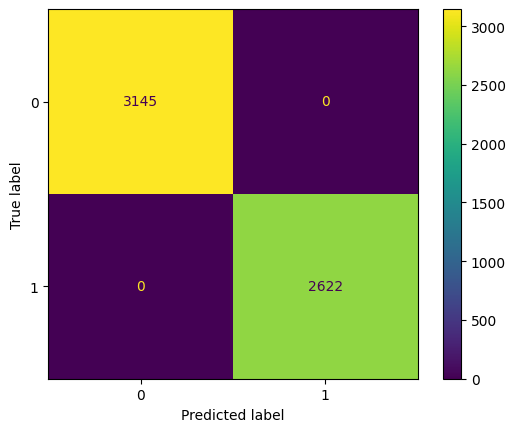

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(final_best_model, X_test, y_test)

In [64]:
X_test.shape

(5767, 31)